In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from glob import glob

import librosa 
import librosa.display
import IPython.display as ipd

from itertools import cycle

In [2]:
sns.set_theme(style = "white", palette = None)
color_pal = plt.rcParams["axes.prop_cycle"].by_key()["color"]
color_cycle = cycle(plt.rcParams["axes.prop_cycle"].by_key()["color"])

In [3]:
audio_files = glob('./dataset/*/*.wav')

In [4]:
ipd.Audio(audio_files[0])

In [5]:
y, sr = librosa.load(audio_files[0])
print(f'y: {y[:10]}')
print(f'y shape: {y.shape}')
print(f'sr: {sr}')

y: [ 5.3765390e-08 -2.1233145e-08 -6.0478342e-09  3.8985988e-08
 -7.6543131e-08  1.1907758e-07 -1.6708444e-07  2.2135782e-07
 -2.8319053e-07  3.5470680e-07]
y shape: (72838,)
sr: 22050


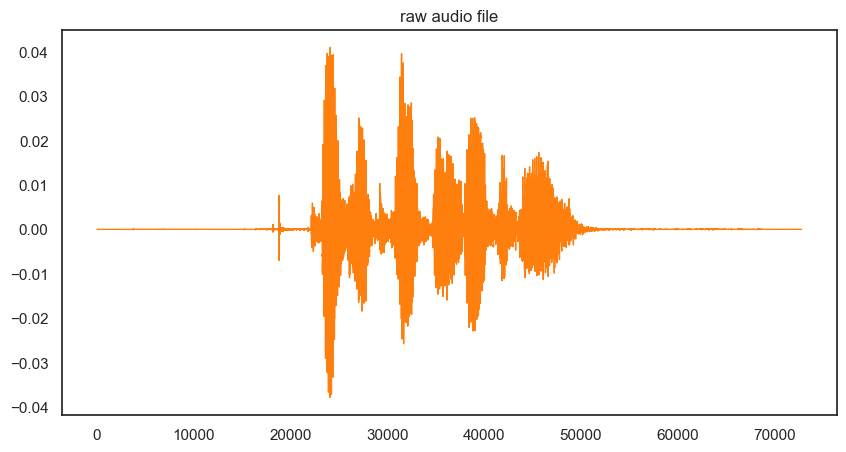

In [6]:
pd.Series(y).plot(figsize = (10, 5), 
                  lw = 1, 
                  title = 'raw audio file',
                  color = color_pal[1])
plt.show()

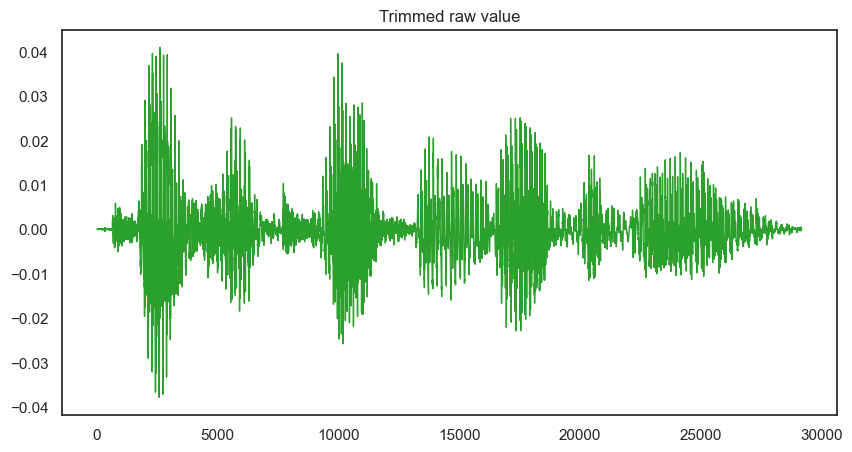

In [7]:
y_trimmed, _ = librosa.effects.trim(y, top_db = 30)
pd.Series(y_trimmed).plot(figsize = (10, 5),
                          lw = 1,
                          color = color_pal[2],
                          title = 'Trimmed raw value')
plt.show()

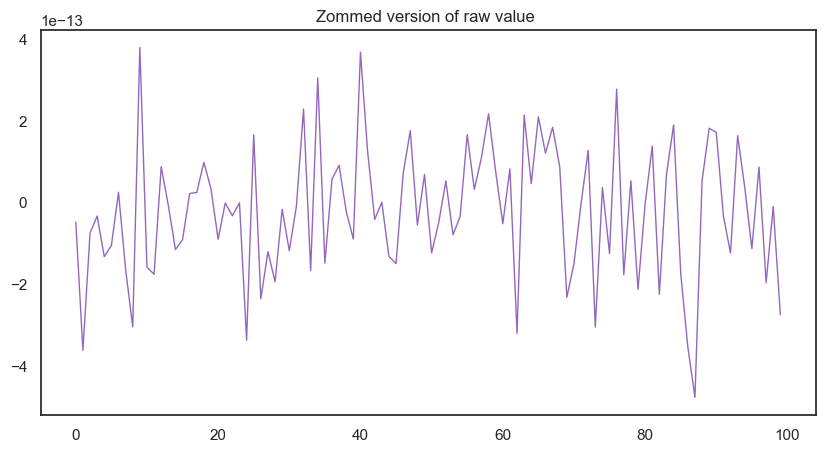

In [8]:
pd.Series(y[10000:10100]).plot(figsize = (10, 5),
                               color = color_pal[4],
                               lw = 1,
                               title= 'Zommed version of raw value ')
plt.show()

### Spectogram

In [9]:
D = librosa.stft(y)
S_db = librosa.amplitude_to_db(np.abs(D), ref = np.max)